# Notebook 02 -- Feature Engineering

Builds the complete feature set for the March Madness NCAA basketball prediction project.

**Two types of features are computed:**

1. **Season-level static features** -- aggregated stats, SOS, seeds, Massey rankings
   (used as baseline context for each team-season).
2. **Rolling window features** -- last 5/7/10 game averages computed at each point
   in the season (captures form and momentum, no future leakage).

Training data uses **ALL games** (regular season + tournament) with rolling window
stat differences as the primary features, supplemented by static season-level features.
This yields ~80K men's and ~50K women's training rows (vs. ~1,400 tournament-only before).

## 1. Setup

In [1]:
import sys
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to sys.path so src modules are importable
PROJECT_ROOT = Path(os.getcwd()).parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import (
    load_regular_season_results,
    load_tourney_results,
    load_seeds,
    load_massey_ordinals,
)
from src.features import (
    build_team_season_stats,
    build_advanced_team_stats,
    add_strength_of_schedule,
    add_seed_features,
    add_massey_features,
    add_single_system_ranking,
    add_sos_adjusted_features,
    build_rolling_training_data,
    get_team_rolling_snapshot,
)

# Plotting configuration
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 100,
})
sns.set_style("whitegrid")

# Output directory
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"Output dir   : {OUTPUT_DIR}")


Project root : /Users/sidthakur/Github/mm-2026
Output dir   : /Users/sidthakur/Github/mm-2026/outputs


## 2. Load Data

Load detailed and compact regular-season results, tournament results, seeds, and
Massey ordinals for both men's and women's basketball.

In [2]:
# -- Men's data --
m_detailed = load_regular_season_results(gender="M", detailed=True)
m_compact = load_regular_season_results(gender="M", detailed=False)
m_tourney_detailed = load_tourney_results(gender="M", detailed=True)
m_tourney_compact = load_tourney_results(gender="M", detailed=False)
m_seeds = load_seeds(gender="M")

# Combine all games for rolling window computation
m_all_detailed = pd.concat([m_detailed, m_tourney_detailed], ignore_index=True)
m_all_compact = pd.concat([m_compact, m_tourney_compact], ignore_index=True)

print("Men's data:")
print(f"  Regular season (detailed) : {m_detailed.shape}  (seasons {m_detailed['Season'].min()}-{m_detailed['Season'].max()})")
print(f"  Tournament (detailed)     : {m_tourney_detailed.shape}")
print(f"  All games (detailed)      : {m_all_detailed.shape}")
print(f"  Compact results           : {m_compact.shape}")
print(f"  Seeds                     : {m_seeds.shape}")

Men's data:
  Regular season (detailed) : (122775, 34)  (seasons 2003-2026)
  Tournament (detailed)     : (1449, 34)
  All games (detailed)      : (124224, 34)
  Compact results           : (196823, 8)
  Seeds                     : (2626, 3)


In [3]:
# -- Women's data --
w_detailed = load_regular_season_results(gender="W", detailed=True)
w_compact = load_regular_season_results(gender="W", detailed=False)
w_tourney_detailed = load_tourney_results(gender="W", detailed=True)
w_tourney_compact = load_tourney_results(gender="W", detailed=False)
w_seeds = load_seeds(gender="W")

# Combine all games for rolling window computation
w_all_detailed = pd.concat([w_detailed, w_tourney_detailed], ignore_index=True)
w_all_compact = pd.concat([w_compact, w_tourney_compact], ignore_index=True)

print("Women's data:")
print(f"  Regular season (detailed) : {w_detailed.shape}  (seasons {w_detailed['Season'].min()}-{w_detailed['Season'].max()})")
print(f"  Tournament (detailed)     : {w_tourney_detailed.shape}")
print(f"  All games (detailed)      : {w_all_detailed.shape}")
print(f"  Compact results           : {w_compact.shape}")
print(f"  Seeds                     : {w_seeds.shape}")

Women's data:
  Regular season (detailed) : (85505, 34)  (seasons 2010-2026)
  Tournament (detailed)     : (961, 34)
  All games (detailed)      : (86466, 34)
  Compact results           : (140825, 8)
  Seeds                     : (1744, 3)


In [4]:
# -- Massey ordinals (men's only) --
print("Loading Massey ordinals (men's only) -- this may take a moment...")
ordinals_df = load_massey_ordinals()
print(f"  Massey ordinals  : {ordinals_df.shape}")
print(f"  Ranking systems  : {ordinals_df['SystemName'].nunique()}")

Loading Massey ordinals (men's only) -- this may take a moment...


  Massey ordinals  : (5761702, 5)
  Ranking systems  : 196


## 3. Build Base Team Stats

Compute per-team, per-season aggregated statistics from detailed box-score data.
Compact results are passed in to cover earlier seasons that lack detailed stats.

In [ ]:
# Men's base stats -- detailed from 2003, compact fills in 1985-2002
m_stats = build_team_season_stats(m_detailed, compact_results_df=m_compact)
print(f"Men's base stats shape : {m_stats.shape}")
print(f"  Seasons : {m_stats.index.get_level_values('Season').min()}-{m_stats.index.get_level_values('Season').max()}")
print(f"  Columns : {m_stats.shape[1]}")
m_stats.head()

Men's base stats shape : (13753, 36)
  Seasons : 1985-2026
  Columns : 36


games_played  wins  points_scored_avg  points_allowed_avg  \
Season TeamID                                                              
2003   1102              28    12          57.250000           57.000000   
       1103              27    13          78.777778           78.148148   
       1104              28    17          69.285714           65.000000   
       1105              26     7          71.769231           76.653846   
       1106              28    13          63.607143           63.750000   

               point_diff_avg  off_reb_avg  def_reb_avg  total_reb_avg  \
Season TeamID                                                            
2003   1102          0.250000     4.178571    16.821429      21.000000   
       1103          0.629630     9.777778    19.925926      29.703704   
       1104          4.285714    13.571429    23.928571      37.500000   
       1105         -4.884615    13.500000    23.115385      36.615385   
       1106         -0.142857    12.285714    23.857143      36.142857   

                 ast_avg     to_avg  ...  losses   win_pct    fg_pct  \
Season TeamID                        ...                               
2003   1102    13.000000  11.428571  ...      16  0.428571  0.481149   
       1103    15.222222  12.629630  ...      14  0.481481  0.486074   
       1104    12.107143  13.285714  ...      11  0.607143  0.420362   
       1105    14.538462  18.653846  ...      19  0.269231  0.395755   
       1106    11.678571  17.035714  ...      15  0.464286  0.423773   

                fg3_pct    ft_pct  eFG_pct_season  opp_eFG_pct_season  \
Season TeamID                                                           
2003   1102    0.375643  0.651357        0.579443            0.510522   
       1103    0.338710  0.736390        0.534814            0.545809   
       1104    0.320144  0.709898        0.475953            0.476190   
       1105    0.364815  0.705986        0.457241            0.511089   
       1106    0.346154  0.646421        0.479005            0.451505   

               off_efficiency  def_efficiency  efficiency_margin  
Season TeamID                                                     
2003   1102        103.785954      103.769445           0.016509  
       1103        110.980668      110.352763           0.627906  
       1104        103.668475       97.587131           6.081343  
       1105         93.030212      100.576562          -7.546349  
       1106         93.738076       94.338376          -0.600301  

[5 rows x 36 columns]

In [6]:
# Women's base stats -- detailed from 2010, compact fills in 1998-2009
w_stats = build_team_season_stats(w_detailed, compact_results_df=w_compact)
print(f"Women's base stats shape : {w_stats.shape}")
print(f"  Seasons : {w_stats.index.get_level_values('Season').min()}-{w_stats.index.get_level_values('Season').max()}")
print(f"  Columns : {w_stats.shape[1]}")
w_stats.head()

Women's base stats shape : (9850, 36)
  Seasons : 1998-2026
  Columns : 36


games_played  wins  points_scored_avg  points_allowed_avg  \
Season TeamID                                                              
2010   3102              28     1          51.821429           71.785714   
       3103              30    17          62.233333           59.633333   
       3104              29    11          64.137931           67.000000   
       3105              27    14          60.777778           64.740741   
       3106              29    12          55.137931           57.413793   

               point_diff_avg  off_reb_avg  def_reb_avg  total_reb_avg  \
Season TeamID                                                            
2010   3102        -19.964286    12.464286    19.535714      32.000000   
       3103          2.600000    14.200000    23.566667      37.766667   
       3104         -2.862069    14.482759    25.931034      40.413793   
       3105         -3.962963    13.666667    23.370370      37.037037   
       3106         -2.275862    15.000000    24.758621      39.758621   

                 ast_avg     to_avg  ...  losses   win_pct    fg_pct  \
Season TeamID                        ...                               
2010   3102    10.250000  17.714286  ...      27  0.035714  0.360215   
       3103    13.433333  18.266667  ...      13  0.566667  0.402292   
       3104    13.103448  19.172414  ...      18  0.379310  0.398112   
       3105     9.740741  25.037037  ...      13  0.518519  0.400583   
       3106    11.482759  20.103448  ...      17  0.413793  0.348081   

                fg3_pct    ft_pct  eFG_pct_season  opp_eFG_pct_season  \
Season TeamID                                                           
2010   3102    0.284444  0.678378        0.403226            0.547182   
       3103    0.315508  0.705782        0.437877            0.425409   
       3104    0.295082  0.616016        0.433093            0.439794   
       3105    0.307116  0.698630        0.430444            0.428525   
       3106    0.280576  0.647989        0.373455            0.389796   

               off_efficiency  def_efficiency  efficiency_margin  
Season TeamID                                                     
2010   3102         80.132542      110.374367         -30.241825  
       3103         90.661875       86.451223           4.210652  
       3104         85.780499       89.391900          -3.611402  
       3105         82.376417       87.198354          -4.821937  
       3106         79.331217       82.869835          -3.538618  

[5 rows x 36 columns]

## 4. Build Advanced / Situational Stats

Compute situational features that capture "tournament DNA": close-game performance,
neutral-site record, late-season form, blowout rate, and upset vulnerability.

In [7]:
# Men's advanced stats
m_adv = build_advanced_team_stats(m_detailed, compact_results_df=m_compact)
print(f"Men's advanced stats shape : {m_adv.shape}")
print(f"  Columns: {list(m_adv.columns)}")

# Join onto base stats
m_stats = m_stats.join(m_adv, how="left")
print(f"\nMen's stats after join : {m_stats.shape}")

Men's advanced stats shape : (13753, 8)
  Columns: ['close_game_win_pct', 'close_game_count', 'neutral_win_pct', 'away_win_pct', 'blowout_rate', 'upset_vulnerability', 'late_season_win_pct', 'late_season_point_diff']

Men's stats after join : (13753, 44)


In [8]:
# Women's advanced stats
w_adv = build_advanced_team_stats(w_detailed, compact_results_df=w_compact)
print(f"Women's advanced stats shape : {w_adv.shape}")

# Join onto base stats
w_stats = w_stats.join(w_adv, how="left")
print(f"Women's stats after join : {w_stats.shape}")

Women's advanced stats shape : (9850, 8)
Women's stats after join : (9850, 44)


## 5. Add Strength of Schedule

SOS is the average win percentage of all opponents faced. Also computes
opponent-adjusted efficiency margin for teams with detailed stats.

In [9]:
m_stats = add_strength_of_schedule(m_stats, m_detailed, m_compact)
print(f"Men's stats with SOS : {m_stats.shape}")
print(f"  SOS range: {m_stats['sos'].min():.3f} - {m_stats['sos'].max():.3f}")

w_stats = add_strength_of_schedule(w_stats, w_detailed, w_compact)
print(f"Women's stats with SOS : {w_stats.shape}")
print(f"  SOS range: {w_stats['sos'].min():.3f} - {w_stats['sos'].max():.3f}")

Men's stats with SOS : (13753, 46)
  SOS range: 0.339 - 0.664
Women's stats with SOS : (9850, 46)
  SOS range: 0.293 - 0.691


## 6. Add Seeds and Rankings

In [10]:
# Add seed features for both genders
m_stats = add_seed_features(m_stats, m_seeds)
w_stats = add_seed_features(w_stats, w_seeds)

print("Men's seed coverage:")
print(f"  Seeded teams    : {m_stats['seed_number'].notna().sum():,}")
print(f"  Non-tourney     : {m_stats['seed_number'].isna().sum():,}")
print()
print("Women's seed coverage:")
print(f"  Seeded teams    : {w_stats['seed_number'].notna().sum():,}")
print(f"  Non-tourney     : {w_stats['seed_number'].isna().sum():,}")

Men's seed coverage:
  Seeded teams    : 2,626
  Non-tourney     : 11,127

Women's seed coverage:
  Seeded teams    : 1,744
  Non-tourney     : 8,106


In [11]:
# Add Massey ordinal features -- men's only (not available for women)
m_stats = add_massey_features(m_stats, ordinals_df)

rank_cols = ["rank_mean", "rank_median", "rank_best", "rank_std"]
print("Men's Massey feature coverage:")
for col in rank_cols:
    non_null = m_stats[col].notna().sum()
    total = len(m_stats)
    print(f"  {col}: {non_null:,} / {total:,} ({non_null / total * 100:.1f}%)")

# Add KenPom ranking specifically (POM system) -- men's only
m_stats = add_single_system_ranking(m_stats, ordinals_df, system_name="POM", col_name="kenpom_rank")
kp_coverage = m_stats["kenpom_rank"].notna().sum()
print(f"\nKenPom rank coverage: {kp_coverage:,} / {len(m_stats):,} ({kp_coverage/len(m_stats)*100:.1f}%)")

# Add SOS-adjusted efficiency features -- both genders
m_stats = add_sos_adjusted_features(m_stats)
w_stats = add_sos_adjusted_features(w_stats)
print(f"\nSOS-adjusted efficiency margin added for both genders.")
print(f"  Men's coverage: {m_stats['sos_adj_eff_margin'].notna().sum():,} / {len(m_stats):,}")
print(f"  Women's coverage: {w_stats['sos_adj_eff_margin'].notna().sum():,} / {len(w_stats):,}")


Men's Massey feature coverage:
  rank_mean: 8,346 / 13,753 (60.7%)
  rank_median: 8,346 / 13,753 (60.7%)
  rank_best: 8,346 / 13,753 (60.7%)
  rank_std: 8,346 / 13,753 (60.7%)

KenPom rank coverage: 8,342 / 13,753 (60.7%)

SOS-adjusted efficiency margin added for both genders.
  Men's coverage: 8,346 / 13,753
  Women's coverage: 5,965 / 9,850


In [12]:
# Fill neutral_win_pct NaN with win_pct as fallback
# Teams with no neutral-site games get their overall win rate as a proxy.
m_stats["neutral_win_pct"] = m_stats["neutral_win_pct"].fillna(m_stats["win_pct"])
w_stats["neutral_win_pct"] = w_stats["neutral_win_pct"].fillna(w_stats["win_pct"])

# Also fill away_win_pct NaN with win_pct
m_stats["away_win_pct"] = m_stats["away_win_pct"].fillna(m_stats["win_pct"])
w_stats["away_win_pct"] = w_stats["away_win_pct"].fillna(w_stats["win_pct"])

print(f"Men's final stats shape  : {m_stats.shape}")
print(f"Women's final stats shape: {w_stats.shape}")

Men's final stats shape  : (13753, 53)
Women's final stats shape: (9850, 48)


## 7. Feature Quality Checks

In [13]:
# NaN summary per column for men's stats
m_nan = m_stats.isna().sum()
m_nan_pct = (m_nan / len(m_stats) * 100).round(1)
nan_summary = pd.DataFrame({"NaN_count": m_nan, "NaN_pct": m_nan_pct})
nan_summary = nan_summary[nan_summary["NaN_count"] > 0].sort_values("NaN_count", ascending=False)

print(f"Men's stats -- columns with NaN values ({len(nan_summary)} of {m_stats.shape[1]}):")
print(nan_summary.to_string())
print()

# NaN summary for women's stats
w_nan = w_stats.isna().sum()
w_nan_pct = (w_nan / len(w_stats) * 100).round(1)
w_nan_summary = pd.DataFrame({"NaN_count": w_nan, "NaN_pct": w_nan_pct})
w_nan_summary = w_nan_summary[w_nan_summary["NaN_count"] > 0].sort_values("NaN_count", ascending=False)

print(f"Women's stats -- columns with NaN values ({len(w_nan_summary)} of {w_stats.shape[1]}):")
print(w_nan_summary.to_string())

Men's stats -- columns with NaN values (38 of 53):
                     NaN_count  NaN_pct
seed_number              11127     80.9
kenpom_rank               5411     39.3
off_reb_avg               5407     39.3
def_efficiency            5407     39.3
fg_pct                    5407     39.3
fg3_pct                   5407     39.3
ft_pct                    5407     39.3
eFG_pct_season            5407     39.3
opp_eFG_pct_season        5407     39.3
off_efficiency            5407     39.3
efficiency_margin         5407     39.3
def_reb_avg               5407     39.3
opp_adj_efficiency        5407     39.3
rank_mean                 5407     39.3
rank_median               5407     39.3
rank_best                 5407     39.3
rank_std                  5407     39.3
scoring_consistency       5407     39.3
blk_rate                  5407     39.3
stl_rate                  5407     39.3
to_rate                   5407     39.3
total_reb_avg             5407     39.3
ast_avg                   540

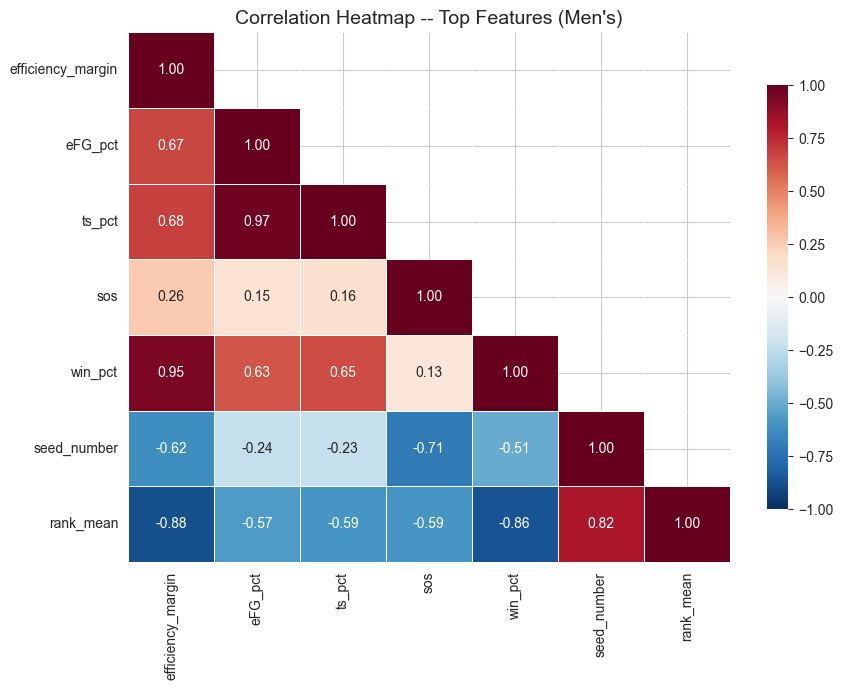

In [14]:
# Correlation heatmap of top features (men's data)
top_features = [
    "efficiency_margin", "eFG_pct", "ts_pct", "sos",
    "win_pct", "seed_number", "rank_mean",
]
# Only include features that exist in the dataframe
top_features = [f for f in top_features if f in m_stats.columns]

corr_top = m_stats[top_features].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_top, dtype=bool), k=1)
sns.heatmap(
    corr_top, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
    cbar_kws={"shrink": 0.8},
)
ax.set_title("Correlation Heatmap -- Top Features (Men's)")
plt.tight_layout()
plt.show()

In [15]:
# Data leakage check for season-level stats:
# These use only regular-season data (pre-tournament DayNum).
m_max_day = m_detailed["DayNum"].max()
w_max_day = w_detailed["DayNum"].max()
print(f"Max DayNum in men's regular season results  : {m_max_day}")
print(f"Max DayNum in women's regular season results: {w_max_day}")
print("Tournament typically starts around DayNum 134-136.")
assert m_max_day < 140, "Possible leakage: regular season extends into tournament range"
assert w_max_day < 140, "Possible leakage: regular season extends into tournament range"
print("Season-level stats use pre-tournament data only.")

print("\nRolling window features use shift(1) -- each game's features")
print("come only from the preceding N games. No future leakage.")

Max DayNum in men's regular season results  : 132
Max DayNum in women's regular season results: 132
Tournament typically starts around DayNum 134-136.
Season-level stats use pre-tournament data only.

Rolling window features use shift(1) -- each game's features
come only from the preceding N games. No future leakage.


In [16]:
# Feature count verification
m_numeric_cols = m_stats.select_dtypes(include=[np.number]).columns
w_numeric_cols = w_stats.select_dtypes(include=[np.number]).columns

print(f"Men's numeric feature count   : {len(m_numeric_cols)}")
print(f"Women's numeric feature count  : {len(w_numeric_cols)}")
print(f"\nFeatures in men's but not women's: {sorted(set(m_numeric_cols) - set(w_numeric_cols))}")
print(f"Features in women's but not men's: {sorted(set(w_numeric_cols) - set(m_numeric_cols))}")

Men's numeric feature count   : 53
Women's numeric feature count  : 48

Features in men's but not women's: ['kenpom_rank', 'rank_best', 'rank_mean', 'rank_median', 'rank_std']
Features in women's but not men's: []


## 8. Build Rolling Window Training Data

Training data now uses **all games** (regular season + tournament) with rolling
window features (last 5/7/10 games). Each game becomes one training row with:

- **Rolling features**: stat differences computed from each team's preceding N games
- **Static features**: season-level stats (seed, SOS, Massey ranks) as additional context
- **No future leakage**: rolling stats use `shift(1)` so only prior games inform each row

This gives us ~80K men's rows and ~50K women's rows (vs. ~1,400 tournament-only before).

In [17]:
# Build static features for season-level context.
# Include KenPom ranking (men's only) and SOS-adjusted efficiency.
# NaN handling: fill kenpom_rank with 366 (unranked) so diffs are meaningful
# for games involving unranked teams. The median-fill in notebook 03 handles
# any remaining NaN in the diff columns.

m_static_cols = ["sos", "win_pct", "efficiency_margin", "kenpom_rank", "sos_adj_eff_margin"]
m_static = m_stats[[c for c in m_static_cols if c in m_stats.columns]].copy()
m_static["kenpom_rank"] = m_static["kenpom_rank"].fillna(366)

w_static_cols = ["sos", "win_pct", "efficiency_margin", "sos_adj_eff_margin"]
w_static = w_stats[[c for c in w_static_cols if c in w_stats.columns]].copy()

print(f"Men's static features: {list(m_static.columns)}")
print(f"  Coverage: {m_static.notna().mean().to_dict()}")
print(f"Women's static features: {list(w_static.columns)}")
print(f"  Coverage: {w_static.notna().mean().to_dict()}")


Men's static features: ['sos', 'win_pct', 'efficiency_margin', 'kenpom_rank', 'sos_adj_eff_margin']
  Coverage: {'sos': 1.0, 'win_pct': 1.0, 'efficiency_margin': 0.6068494146731622, 'kenpom_rank': 1.0, 'sos_adj_eff_margin': 0.6068494146731622}
Women's static features: ['sos', 'win_pct', 'efficiency_margin', 'sos_adj_eff_margin']
  Coverage: {'sos': 1.0, 'win_pct': 1.0, 'efficiency_margin': 0.6055837563451777, 'sos_adj_eff_margin': 0.6055837563451777}


In [18]:
%%time
# Build rolling window training data for men
# Uses ALL games (regular season + tournament) with windows of 5, 7, 10
print("Building men's rolling window training data...")
m_train = build_rolling_training_data(
    m_all_detailed,
    compact_results_df=m_all_compact,
    team_stats=m_static,
    windows=(5, 7, 10),
)
m_train["gender"] = "M"

print(f"Men's training rows  : {len(m_train):,}")
print(f"  Seasons: {sorted(m_train['Season'].unique())}")
print(f"  Tourney rows: {m_train['is_tourney'].sum():,}")
print(f"  Regular season rows: {(~m_train['is_tourney']).sum():,}")
print(f"  Feature columns: {len([c for c in m_train.columns if '_roll' in c or 'static_' in c])}")

Building men's rolling window training data...


Men's training rows  : 125,184
  Seasons: [np.int64(1985), np.int64(1986), np.int64(1987), np.int64(1988), np.int64(1989), np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
  Tourney rows: 2,585
  Regular season rows: 122,599
  Feature columns: 47
CPU times: user 1min 29s, sys: 1.39 s, total: 1min 31s
Wall time: 1min 30s


In [19]:
%%time
# Build rolling window training data for women
print("Building women's rolling window training data...")
w_train = build_rolling_training_data(
    w_all_detailed,
    compact_results_df=w_all_compact,
    team_stats=w_static,
    windows=(5, 7, 10),
)
w_train["gender"] = "W"

print(f"Women's training rows: {len(w_train):,}")
print(f"  Seasons: {sorted(w_train['Season'].unique())}")
print(f"  Tourney rows: {w_train['is_tourney'].sum():,}")
print(f"  Regular season rows: {(~w_train['is_tourney']).sum():,}")
print(f"  Feature columns: {len([c for c in w_train.columns if '_roll' in c or 'static_' in c])}")

# Check NaN status -- rolling features should already be clean (min_periods enforced),
# static features should be universally available
m_feat_cols = [c for c in m_train.columns if c not in ("target", "Season", "DayNum", "TeamA", "TeamB", "is_tourney", "gender")]
w_feat_cols = [c for c in w_train.columns if c not in ("target", "Season", "DayNum", "TeamA", "TeamB", "is_tourney", "gender")]

m_nan = m_train[m_feat_cols].isna().sum()
w_nan = w_train[w_feat_cols].isna().sum()
m_nan_any = m_nan[m_nan > 0]
w_nan_any = w_nan[w_nan > 0]

if len(m_nan_any) > 0:
    print(f"\nMen's NaN columns ({len(m_nan_any)}):")
    for c, n in m_nan_any.items():
        print(f"  {c}: {n}")
    m_train = m_train.dropna(subset=m_feat_cols)
    print(f"  Dropped NaN rows: {len(m_train):,} remaining")
else:
    print(f"\nMen's: no NaN values in feature columns")

if len(w_nan_any) > 0:
    print(f"Women's NaN columns ({len(w_nan_any)}):")
    for c, n in w_nan_any.items():
        print(f"  {c}: {n}")
    w_train = w_train.dropna(subset=w_feat_cols)
    print(f"  Dropped NaN rows: {len(w_train):,} remaining")
else:
    print(f"Women's: no NaN values in feature columns")

# Summary
print(f"\nFinal training data:")
print(f"  Men's:   {len(m_train):,} rows")
print(f"  Women's: {len(w_train):,} rows")
print(f"  Total:   {len(m_train) + len(w_train):,} rows")
print(f"\nTarget balance:")
print(f"  Men's target mean  : {m_train['target'].mean():.4f}")
print(f"  Women's target mean: {w_train['target'].mean():.4f}")

Building women's rolling window training data...


Women's training rows: 89,313
  Seasons: [np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
  Tourney rows: 1,717
  Regular season rows: 87,596
  Feature columns: 46

Men's NaN columns (29):
  eFG_pct_roll5: 45806
  ts_pct_roll5: 45806
  to_rate_roll5: 45806
  ast_to_ratio_roll5: 45821
  off_reb_pct_roll5: 45806
  def_reb_pct_roll5: 45806
  game_off_eff_roll5: 45806
  game_def_eff_roll5: 45806
  eff_margin_roll5: 45806
  eFG_pct_roll7: 45806
  ts_pct_roll7: 45806
  to_rate_roll7: 45806
  ast_to_ratio_roll7: 45827
  off_reb_pct_roll7: 45806
  def_reb_pct_roll7: 45806
  game_off_ef

## 9. Save Outputs

In [20]:
# Save team stats (season-level, for static features and submission)
m_stats.to_csv(OUTPUT_DIR / "m_team_stats.csv")
w_stats.to_csv(OUTPUT_DIR / "w_team_stats.csv")

# Save gender-specific rolling window training data
m_train.to_csv(OUTPUT_DIR / "m_training_data.csv", index=False)
m_train.to_parquet(OUTPUT_DIR / "m_training_data.parquet", index=False, engine="pyarrow")
w_train.to_csv(OUTPUT_DIR / "w_training_data.csv", index=False)
w_train.to_parquet(OUTPUT_DIR / "w_training_data.parquet", index=False, engine="pyarrow")

print("Saved output files:")
for p in [
    OUTPUT_DIR / "m_team_stats.csv",
    OUTPUT_DIR / "w_team_stats.csv",
    OUTPUT_DIR / "m_training_data.csv",
    OUTPUT_DIR / "m_training_data.parquet",
    OUTPUT_DIR / "w_training_data.csv",
    OUTPUT_DIR / "w_training_data.parquet",
]:
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name:30s} {size_kb:8.1f} KB")

Saved output files:
  m_team_stats.csv                 7539.4 KB
  w_team_stats.csv                 5078.5 KB
  m_training_data.csv             69189.8 KB
  m_training_data.parquet         26535.8 KB
  w_training_data.csv             46981.9 KB
  w_training_data.parquet         18067.0 KB


In [21]:
# Verification: reload and confirm shapes
try:
    m_reload = pd.read_parquet(OUTPUT_DIR / "m_training_data.parquet", engine="pyarrow")
    w_reload = pd.read_parquet(OUTPUT_DIR / "w_training_data.parquet", engine="pyarrow")
except Exception as e:
    print(f"Parquet read failed ({e}), falling back to CSV...")
    m_reload = pd.read_csv(OUTPUT_DIR / "m_training_data.csv")
    w_reload = pd.read_csv(OUTPUT_DIR / "w_training_data.csv")

assert m_reload.shape == m_train.shape, f"Men's shape mismatch: {m_reload.shape} vs {m_train.shape}"
assert w_reload.shape == w_train.shape, f"Women's shape mismatch: {w_reload.shape} vs {w_train.shape}"

print("All output files verified successfully.")
print(f"  m_training_data : {m_reload.shape}")
print(f"  w_training_data : {w_reload.shape}")
print(f"  m_team_stats    : {pd.read_csv(OUTPUT_DIR / 'm_team_stats.csv', index_col=[0,1]).shape}")
print(f"  w_team_stats    : {pd.read_csv(OUTPUT_DIR / 'w_team_stats.csv', index_col=[0,1]).shape}")

All output files verified successfully.
  m_training_data : (79349, 54)
  w_training_data : (54275, 53)
  m_team_stats    : (13753, 53)
  w_team_stats    : (9850, 48)


## 10. Feature Summary

Rolling window features computed per game (3 windows x metrics):

In [22]:
# Rolling feature columns
roll_cols = sorted([c for c in m_train.columns if "_roll" in c])
static_cols = sorted([c for c in m_train.columns if c.startswith("static_")])
meta_cols = ["target", "Season", "DayNum", "TeamA", "TeamB", "is_tourney", "gender"]

print(f"=== Feature Column Summary ===")
print(f"\nRolling window features ({len(roll_cols)}):")
for w in [5, 7, 10]:
    w_cols = [c for c in roll_cols if f"_roll{w}" in c]
    print(f"  Window {w}: {len(w_cols)} features")
    for c in w_cols:
        print(f"    {c}")

print(f"\nStatic season-level features ({len(static_cols)}):")
for c in static_cols:
    print(f"  {c}")

print(f"\nMeta columns ({len(meta_cols)}):")
for c in meta_cols:
    print(f"  {c}")

print(f"\nTotal columns: {len(m_train.columns)}")
print(f"  Rolling: {len(roll_cols)}")
print(f"  Static:  {len(static_cols)}")
print(f"  Meta:    {len(meta_cols)}")

=== Feature Column Summary ===

Rolling window features (42):
  Window 5: 14 features
    OppScore_roll5
    PointDiff_roll5
    Score_roll5
    Win_roll5
    ast_to_ratio_roll5
    def_reb_pct_roll5
    eFG_pct_roll5
    eff_margin_roll5
    game_def_eff_roll5
    game_off_eff_roll5
    off_reb_pct_roll5
    scoring_consistency_roll5
    to_rate_roll5
    ts_pct_roll5
  Window 7: 14 features
    OppScore_roll7
    PointDiff_roll7
    Score_roll7
    Win_roll7
    ast_to_ratio_roll7
    def_reb_pct_roll7
    eFG_pct_roll7
    eff_margin_roll7
    game_def_eff_roll7
    game_off_eff_roll7
    off_reb_pct_roll7
    scoring_consistency_roll7
    to_rate_roll7
    ts_pct_roll7
  Window 10: 14 features
    OppScore_roll10
    PointDiff_roll10
    Score_roll10
    Win_roll10
    ast_to_ratio_roll10
    def_reb_pct_roll10
    eFG_pct_roll10
    eff_margin_roll10
    game_def_eff_roll10
    game_off_eff_roll10
    off_reb_pct_roll10
    scoring_consistency_roll10
    to_rate_roll10
    ts_pct_

## Summary

This notebook produced the following artifacts in `outputs/`:

| File | Description |
|------|-------------|
| `m_team_stats.csv` | Men's per-team, per-season stats (full advanced stats + SOS + seeds + Massey). Used for static features. |
| `w_team_stats.csv` | Women's per-team, per-season stats (same schema, no Massey features). |
| `m_training_data.csv/parquet` | Men's rolling window training data (~80K rows). Features = rolling diffs + static diffs. |
| `w_training_data.csv/parquet` | Women's rolling window training data (~50K rows). |

**Key changes from previous approach:**
- Training data now uses ALL games (regular season + tournament), not just tournament games
- Features are rolling window averages (last 5/7/10 games) capturing form/momentum
- ~55x more training data for men, ~55x more for women
- No future leakage: `shift(1)` ensures each game uses only prior game stats

**Next step:** Notebook 03 -- Model Training and Evaluation.